In [1]:
import logging, warnings
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import spearmanr, ConstantInputWarning
from tqdm import tqdm
from umap import UMAP
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib
import importlib

from src.utils import iter_dataset_dirs, load_json
from src.plot_style import apply_plot_style
from src.visualization import plot_mts_corr_density, plot_spi_space_individual

apply_plot_style()
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
warnings.simplefilter("ignore", ConstantInputWarning)


/Users/wedi0306/Library/CloudStorage/OneDrive-Personal/Desktop/2025USYD/USYD/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_features_from_cache(cache_path):
    data = np.load(cache_path, allow_pickle=True)
    X = data["X"]
    mts_class = data["mts_class"] if "mts_class" in data.files else data["y"]
    dataset_paths = data["dataset_path"] if "dataset_path" in data.files else data["dataset_paths"]
    meta_df = pd.DataFrame({
        "mts_class": mts_class,
        "variant": data["variant"],
        "M": data["M"],
        "T": data["T"],
        "dataset_path": dataset_paths,
        "instance": data["instance"] if "instance" in data.files else None,
    })
    spi_order = list(data.get("spi_order", []))
    pairs = list(data.get("pairs", []))
    return X, meta_df, spi_order, pairs


In [11]:
X, meta_df, spi_order, pairs = load_features_from_cache("analysis/feature_cache/case_260119.npz")

In [12]:
eps = 1e-8              # “near zero” cutoff; relax to 1e-6 if you want
dom_thresh = 0.99       # flag features that are near zero in ≥99% of datasets

abs_X = np.abs(X)
frac_near_zero = (abs_X < eps).mean(axis=0)      # per-column fraction near zero
all_near_zero = frac_near_zero == 1.0            # exactly zero (within eps) everywhere
dom_near_zero = frac_near_zero >= dom_thresh     # almost always zero

summary = pd.DataFrame({
    "feature_idx": np.arange(X.shape[1]),
    "min": X.min(axis=0),
    "max": X.max(axis=0),
    "frac_near_zero": frac_near_zero,
    "all_near_zero": all_near_zero,
    "dom_near_zero": dom_near_zero,
})
summary_near_zero = summary[summary["dom_near_zero"]].sort_values("frac_near_zero", ascending=False)
summary_near_zero.head()

,feature_idx,min,max,frac_near_zero,all_near_zero,dom_near_zero
24,24,0.0,0.0,1.0,True,True
2750,2750,0.0,0.0,1.0,True,True
2737,2737,0.0,0.0,1.0,True,True
2738,2738,0.0,0.0,1.0,True,True
2739,2739,0.0,0.0,1.0,True,True


In [13]:
# Example if pairs aligns 1:1 with columns
labels = [f"{a} vs {b}" for a, b in pairs]  # adjust to your actual mapping
summary["label"] = labels
summary_near_zero = summary[summary["dom_near_zero"]].sort_values("frac_near_zero", ascending=False)
summary_near_zero[["feature_idx", "label", "frac_near_zero", "min", "max"]].head(20)


,feature_idx,label,frac_near_zero,min,max
24,24,cov_EmpiricalCovariance vs corr_pearson_tau-1,1.0,0.0,0.0
2750,2750,corr_pearson_tau-10 vs cohmag_multitaper_mean_...,1.0,0.0,0.0
2737,2737,corr_pearson_tau-10 vs pdist_cityblock,1.0,0.0,0.0
2738,2738,corr_pearson_tau-10 vs pdist_cosine,1.0,0.0,0.0
2739,2739,corr_pearson_tau-10 vs pdist_chebyshev,1.0,0.0,0.0
2740,2740,corr_pearson_tau-10 vs pdist_canberra,1.0,0.0,0.0
2741,2741,corr_pearson_tau-10 vs pdist_braycurtis,1.0,0.0,0.0
2742,2742,corr_pearson_tau-10 vs anm,1.0,0.0,0.0
2743,2743,corr_pearson_tau-10 vs te_kraskov_NN-4_DCE_k-1...,1.0,0.0,0.0
2744,2744,corr_pearson_tau-10 vs gc_gaussian_k-1_kt-1_l-...,1.0,0.0,0.0


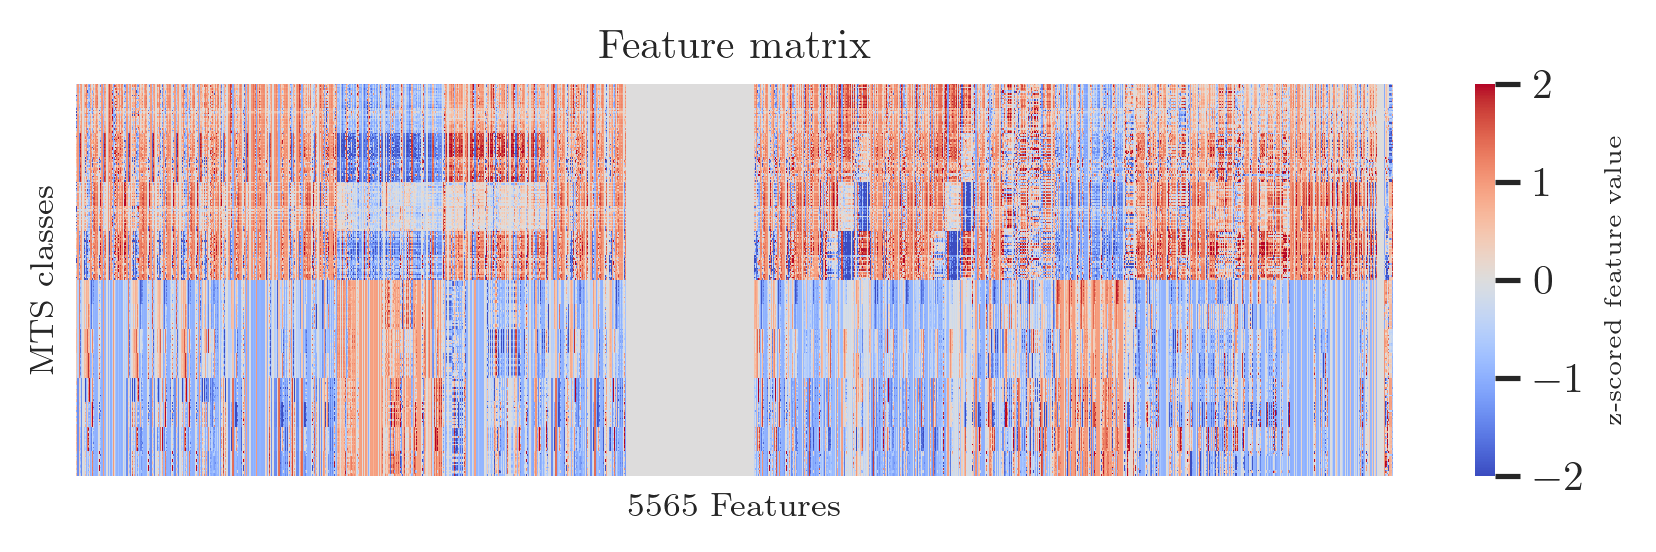

In [14]:
selected_classes = []  # specify desired classes or leave empty for all

if selected_classes:
    noise_mask = meta_df["mts_class"].isin(selected_classes)
    X_selected = X[noise_mask]
    meta_selected = meta_df[noise_mask]
else:
    X_selected = X
    meta_selected = meta_df

# Z-normalize each feature (column) across the selected noise datasets
col_means = X_selected.mean(axis=0)
col_stds = X_selected.std(axis=0)
Xz = (X_selected - col_means) / (col_stds + 1e-9)  # avoid div-by-zero


fig, ax = plt.subplots(figsize=(6, 2), dpi=300)
sns.heatmap(Xz, cmap="coolwarm", cbar=True, ax=ax, vmin=-2, vmax=2)  #cbar_kws={"shrink": 0.8},
ax.collections[0].colorbar.set_label("z-scored feature value", fontsize=6)
ax.set_xlabel(f"{Xz.shape[1]} Features", fontsize=8)
ax.set_ylabel("MTS classes", fontsize=8)
ax.set_xticklabels(""), ax.set_yticklabels("")
ax.set_xticks([]), ax.set_yticks([])
ax.set_title(f"Feature matrix", fontsize=10)
plt.tight_layout()
plt.show()

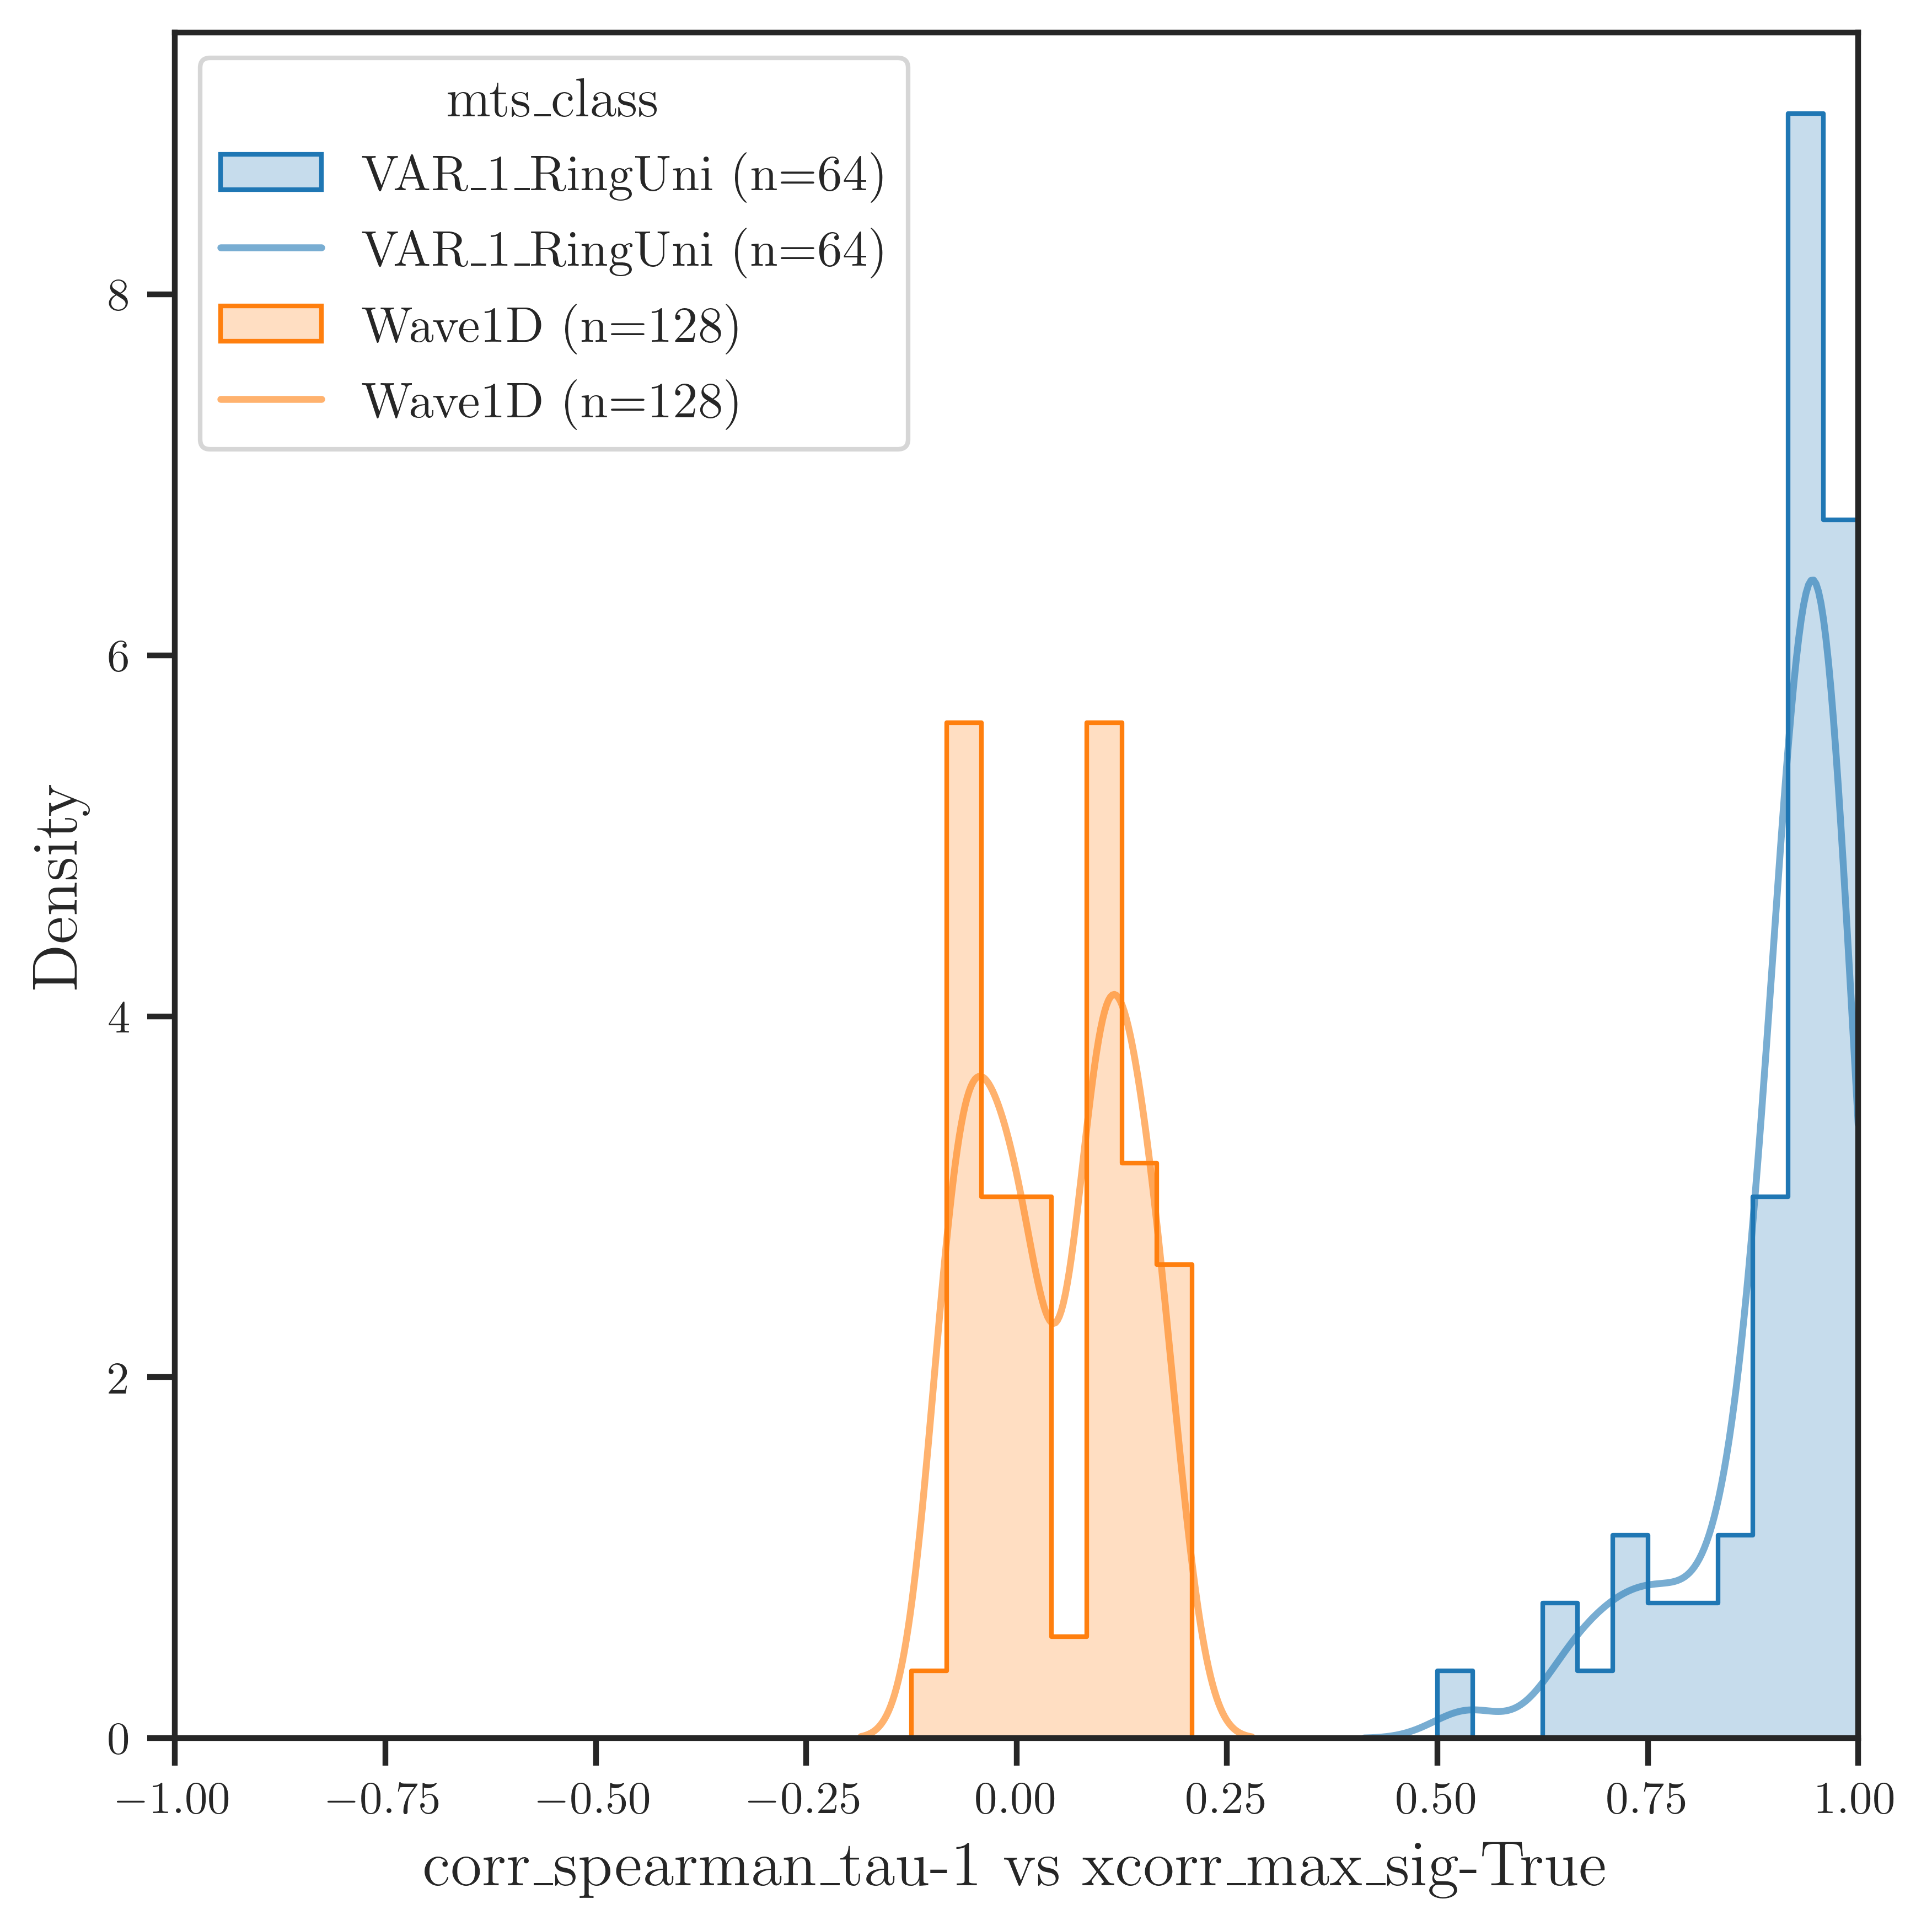

In [29]:
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_spi_space_individual, plot_mts_corr_density_dir, plot_mts_corr_density


plot_mts_corr_density(
    # ["data/case_1/GaussianNoise", "data/case_1/CauchyNoise"],
    "data/case_260119_var_wave/VAR_1_RingUni", "data/case_260119_var_wave/Wave1D",
    # "data/case_260119_var_wave/VAR_1_RingUni", "data/case_260119_var_wave/VAR_1_RingSym",
    ["corr_spearman_tau-1", "xcorr_max_sig-True"],
    # ["cov_EmpiricalCovariance", "kendalltau"],
    # ["spearmanr", "mi_kraskov_NN-4"],
    # ["kendalltau", "pdist_euclidean"], #good
    # ["spearmanr", "cov_EmpiricalCovariance"],
    bw_adjust=1.0,  # optional KDE bandwidth tweak
    show_hist=True,
    bins=48
)